In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import *
import math

#1.Modèle de Heston

Le modèle de Heston est défini par le système d’équations différentielles stochastiques suivant:

\begin{cases}
dS_t = r S_t \, dt + S_t \sqrt{V_t}\, dW_t^{1}, \\
dV_t = \kappa (\theta - V_t)\, dt + \sigma \sqrt{V_t}\, dW_t^{2} \\
d\langle W^{(1)}, W^{2} \rangle_t = \rho\, dt.
\end{cases}


Par construction, $V_t$ est théoriquement positive.



#Discrétisation de $V_t$


Soit $T$ la maturité de l'option. On pose $\Delta t = \frac{T}{N}$ où $N$ est le nombre de pas de discrétisation.

La discrétisation d’Euler du processus de variance $V_t$ est donnée par :

$$V_{t+\Delta t}
=
V_t + \kappa (\theta - V_t)\Delta t
+ \sigma \sqrt{V_t}\sqrt{\Delta t}\, Z,$$ où $Z \sim \mathcal{N}(0,1)$.


Comme $Z$ suit une loi normale centrée réduite, lorsque $V_t$ est petit, $\sigma$ est élevé et $\Delta t$ est trop grand, il est possible que $V_{t+\Delta t} < 0$.
Sous la condition de Feller $2\kappa\theta \ge \sigma^2,$ on a $V_t > 0$ presque sûrement en temps continu.
Cependant, le schéma d'Euler peut produire des valeurs négatives de $V_t$.

Afin d’éviter ces valeurs négatives, on remplace $V_t$ par $\max(V_t,0)$ dans la discrétisation. Le schéma devient alors:
$$
V_{t_{k+1}}
=
V_{t_k}
+ \kappa \bigl(\theta - \max(V_{t_k},0)\bigr)\Delta t
+ \sigma \sqrt{\max(V_{t_k},0)}\,\sqrt{\Delta t}\, Z_{2,k}
$$
avec $Z_{2,k} \sim \mathcal{N}(0,1)$

Le processus du sous-jacent est discrétisé par:
$$
S_{t_{k+1}}
=
S_{t_k}
\exp\!\left[
\left(r - \frac{1}{2}\max(V_{t_k},0)\right)\Delta t
+ \sigma \sqrt{\max(V_{t_k},0)}\,\sqrt{\Delta t}\, Z_{1,k}
\right].
$$ où les variables gaussiennes $Z_{1,k}$ et $Z_{2,k}$ sont corrélées et vérifient :
$Z_{1,k} = \rho Z_{Z_{2,k},k} + \sqrt{1-\rho^2}\, Z_k$ où $Z_k \sim \mathcal{N}(0,1)$.


#Algorithme de simulation Monte Carlo (modèle de Heston)

On fixe le pas de temps $\Delta t = \frac{T}{N}$.

On simule $M$ trajectoires.  
Pour $i = 1,\dots,M$ et pour $k = 0,\dots,N-1$, on procède comme suit:

$$
V^{i}_{t_{k+1}}
=
V^{i}_{t_k}
+ \kappa \bigl(\theta - \max(V^{i}_{t_k},0)\bigr)\Delta t
+ \sigma \sqrt{\max(V^{i}_{t_k},0)}\,\sqrt{\Delta t}\, Z^{i}_{1,k},
$$
où $Z^{i}_{1,k} \sim \mathcal{N}(0,1)$

$$S^{i}_{t_{k+1}}
=
S^{i}_{t_k}
\exp\!\left[
\left(r - \frac{1}{2}\max(V^{i}_{t_k},0)\right)\Delta t
+ \sqrt{\max(V^{i}_{t_k},0)}\,\sqrt{\Delta t}\, Z^{i}_{2,k}
\right].
$$ où les variables gaussiennes sont corrélées par:
$$Z^{i}_{2,k}
=
\rho Z^{i}_{1,k}
+ \sqrt{1-\rho^2}\, Z^{i}_k,
\qquad
Z^{i}_k \sim \mathcal{N}(0,1).
$$

À maturité, on pose: $S_T^{i} = S^{i}_{t_N}$.



##Prix de l'option call européen

Le prix du call est estimé par:
$$
Price_{call}
=
\frac{1}{M} e^{-rT}
\sum_{i=1}^{M}
\max\!\bigl(S_T^{(i)} - K,\, 0\bigr).
$$
##Prix de l'option put européen

Le prix du put est estimé par:
$$
Price_{put}
=
\frac{1}{M} e^{-rT}
\sum_{i=1}^{M}
\max\!\bigl( K -S_T^{(i)}\,, 0\bigr).
$$


##Simulation les trajectoires de la variance et du sous-jacent

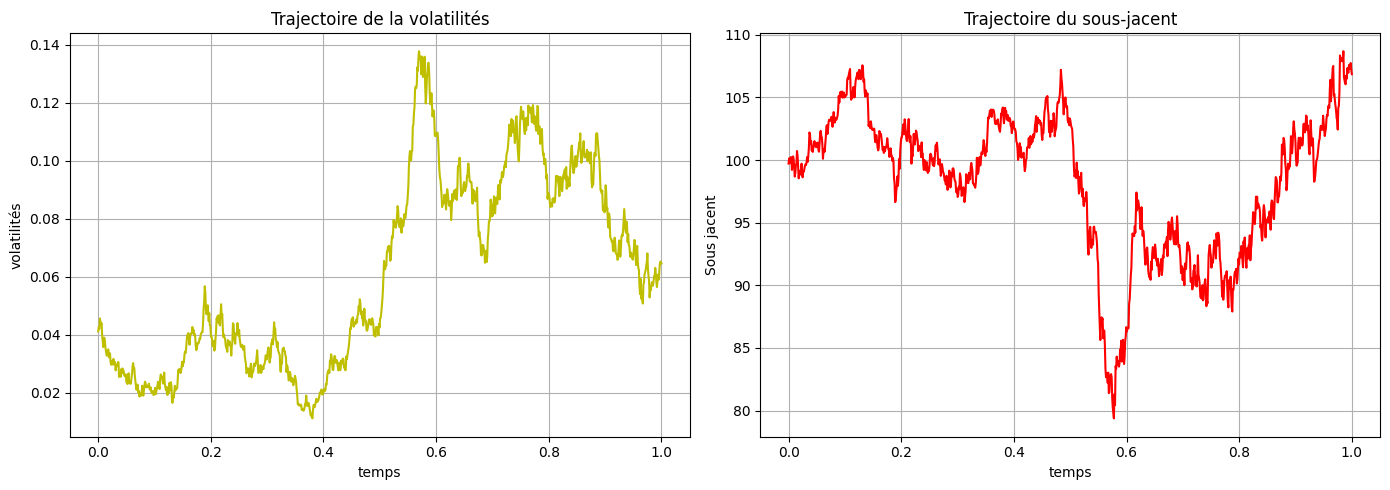

In [ ]:
def Simulation_Heston(S0,V0,r,K,T,N,kappa,theta,rho,sigma):
  dt=T/N
  t=np.linspace(0,1,N)
  V=V0
  S=S0
  vol=[]
  traj=[]
  np.random.seed(42)
  for k in range(N):
    Z1=np.random.randn()
    V=V+kappa*(theta-np.maximum(V,0))*dt+sigma*np.sqrt(dt)*np.sqrt(np.maximum(V,0))*Z1
    Z=rho*Z1+np.sqrt(1-rho**2)*np.random.randn()
    S=S*np.exp((r-0.5*np.maximum(V,0))*dt+np.sqrt(dt)*np.sqrt(np.maximum(V,0))*Z)
    vol.append(V)
    traj.append(S)
  return t,vol,traj
t,vol,traj=Simulation_Heston(100,0.04,0.03,100,1.0,1000,2.5,0.04,-0.7 ,0.35)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(t, vol,'y')
plt.title("Trajectoire de la volatilités")
plt.xlabel("temps")
plt.ylabel("volatilités")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t, traj,'r')
plt.title("Trajectoire du sous-jacent")
plt.xlabel("temps")
plt.ylabel("Sous jacent")
plt.grid(True)

plt.tight_layout()
plt.show()



##L'évolution du prix  du sous-jacent en fonction du souj-jacent

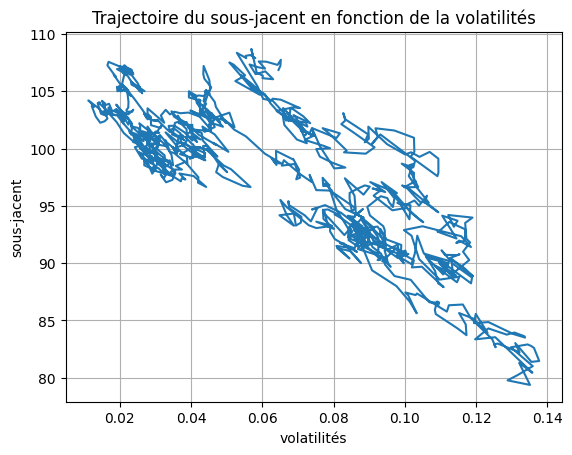

In [ ]:
plt.plot(vol,traj)
plt.title("Trajectoire du sous-jacent en fonction de la volatilités")
plt.xlabel("volatilités")
plt.ylabel("sous-jacent")
plt.grid(True)

##Prix du call estimé

In [ ]:
def Price_Heston_mc(S0, V0, r, K, T, M, N, kappa, theta, rho, sigma):
    dt = T / M
    payoffs = []
    np.random.seed(42)

    for i in range(N):
        S = S0
        V = V0
        for k in range(M):
            Z1 = np.random.randn()
            Z2 = np.random.randn()
            W1 = Z1
            W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
            V = V + kappa * (theta - np.maximum(V, 0.0)) * dt + sigma * np.sqrt(np.maximum(V, 0.0)) * np.sqrt(dt) * W2
            S = S * np.exp((r - 0.5 * np.maximum(V, 0.0)) * dt + np.sqrt(np.maximum(V, 0.0)) * np.sqrt(dt) * W1)
        payoffs.append(np.maximum(S - K, 0.0))

    price_call = np.exp(-r * T) * np.mean(payoffs)
    return price_call

In [ ]:
Price_Heston_mc(100,0.04,0.03,100,1.0,100,100,2.5,0.04,-0.7 ,0.35)

np.float64(3.1396679204354387)

#La sensibilité du prix du call au mouvement de la corrélation entre des browniens

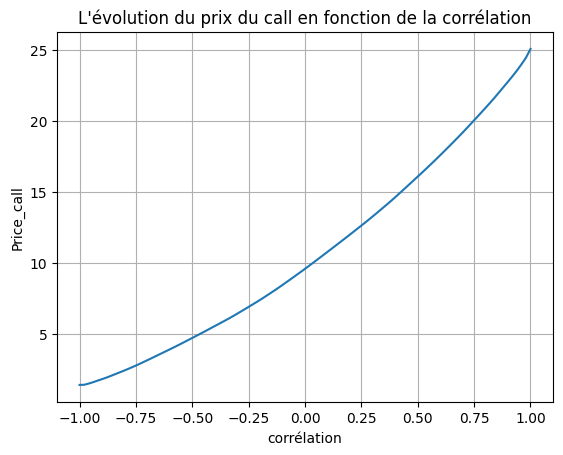

In [ ]:
cors=np.linspace(-1,1,100)
prix=[]
for rho in cors:
  prix.append(Price_Heston_mc(100,0.04,0.03,100,1.0,100,100,2.5,0.04,rho ,0.35))
plt.plot(cors,prix)
plt.title("L'évolution du prix du call en fonction de la corrélation")
plt.xlabel("corrélation")
plt.ylabel("Price_call")
plt.grid(True)

Le graphique montre que le prix du call augmente de façon monotone avec la corrélation $\rho$ entre le mouvement du sous-jacent et celui de sa variance.
Lorsque la corrélation passe de valeurs négatives vers des valeurs positives, le prix du call croît fortement, avec une pente de plus en plus marquée pour les corrélations élevées.

Dans le modèle de Heston, le prix du call est une fonction croissante de la corrélation $\rho$ entre les mouvements browniens
$W_t^1$ et $W_t^2$ gouvernant respectivement le sous-jacent et la variance.
Une corrélation positive amplifie les trajectoires haussières, ce qui accroît la valeur du call, tandis qu'une corrélation négative produit l'effet inverse.

##Sensibilité du prix au mouvement du taux intérêt

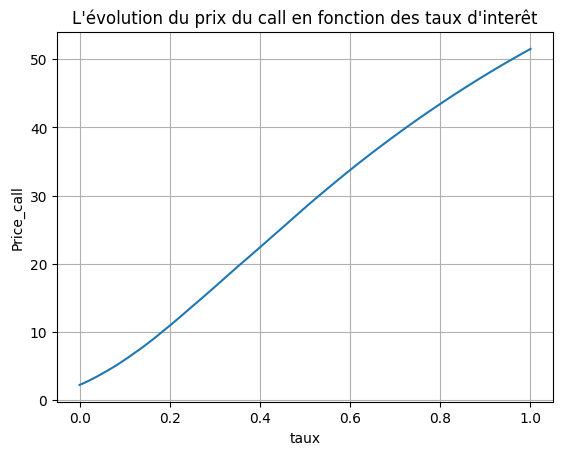

In [ ]:
taux=np.linspace(0,1,100)
prix=[]
for r in taux:
  prix.append(Price_Heston_mc(100,0.04,r,100,1.0,100,100,2.5,0.04,-0.7 ,0.35))
plt.plot(taux,prix)
plt.title("L'évolution du prix du call en fonction des taux d'interêt")
plt.xlabel("taux")
plt.ylabel("Price_call")
plt.grid(True)

On observe que le prix du call est une fonction croissante du taux d'intérêt: lorsque le taux augmente, la valeur du call augmente de manière monotone et non linéaire. Donc le prix du call européen est une fonction croissante du taux d'intérêt sans risque. Une augmentation du taux rend le paiement du strike à maturité moins coûteux en valeur actuelle et accroît la valeur du droit d'achat, ce qui se reflète par une hausse du prix de l'option.

##La sensibilité du prix du call au mouvement de la maturité

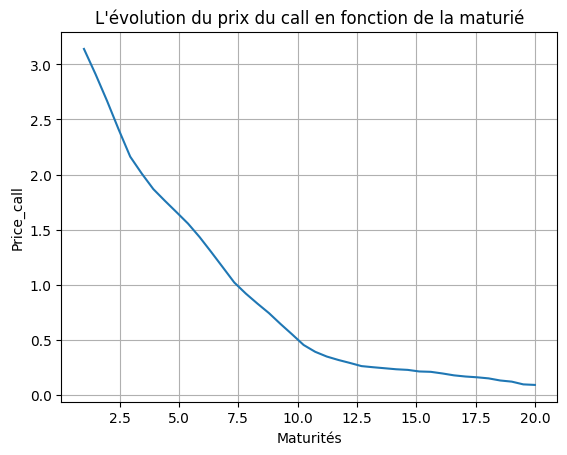

In [ ]:
Maturités=np.linspace(1,20,40)
prix=[]
for T in Maturités:
  prix.append(Price_Heston_mc(100,0.04,0.03,100,T,100,100,2.5,0.04,-0.7 ,0.35))
plt.plot(Maturités,prix)
plt.title("L'évolution du prix du call en fonction de la maturié")
plt.xlabel("Maturités")
plt.ylabel("Price_call")
plt.grid(True)

La courbe montre que le prix du call décroît lorsque la maturité augmente. La baisse est rapide pour les maturités courtes à intermédiaires, puis elle devient plus progressive pour les maturités longues, le prix tendant vers une valeur proche de zéro.

Dans ce contexte, l'augmentation de la maturité ne bénéficie pas au détenteur du call: l'effet d'actualisation et la diminution de la valeur espérée du payoff dominent la valeur temps, ce qui conduit à une décroissance du prix de l'option.

##La sensibilité du prix du call au mouvement du strike

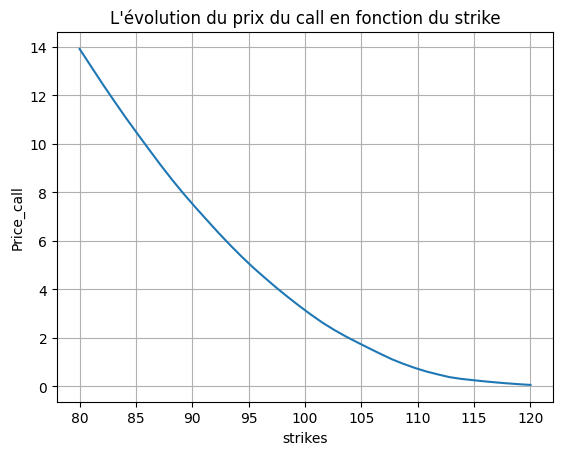

In [ ]:
strikes=np.linspace(80,120,40)
prix=[]
for K in strikes:
  prix.append(Price_Heston_mc(100,0.04,0.03,K,1.0,100,100,2.5,0.04,-0.7 ,0.35))
plt.plot(strikes,prix)
plt.title("L'évolution du prix du call en fonction du strike")
plt.xlabel("strikes")
plt.ylabel("Price_call")
plt.grid(True)

Le prix du call est une fonction décroissante du strike. Une augmentation du prix d’exercice réduit la probabilité que l’option finisse dans la monnaie ainsi que la valeur espérée du payoff, ce qui se traduit par une diminution du prix de l’option.

## L'evolution du prix du call en fonction de la vitesse du retour à la moyenne de la varience

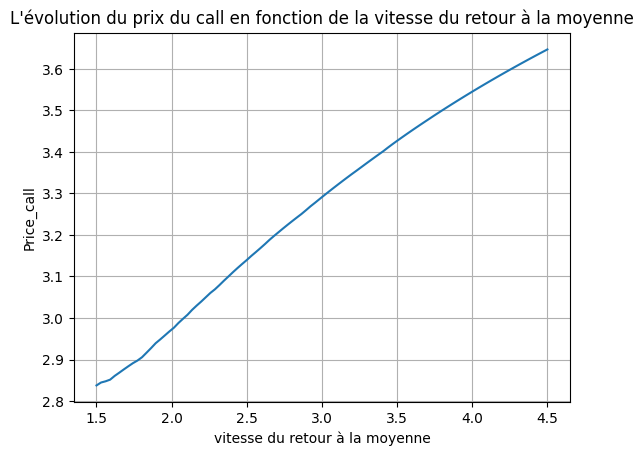

In [ ]:
kappas=np.linspace(1.5,4.5,100)
prix=[]
for kappa in kappas:
  prix.append(Price_Heston_mc(100,0.04,0.03,100,1.0,100,100,kappa,0.04,-0.7 ,0.35))
plt.plot(kappas,prix)
plt.title("L'évolution du prix du call en fonction de la vitesse du retour à la moyenne")
plt.xlabel("vitesse du retour à la moyenne")
plt.ylabel("Price_call")
plt.grid(True)

Le prix du call est une fonction croissante de la vitesse de retour à la moyenne de la variance. Une valeur élevée de ce paramètre renforce la stabilité de la volatilité autour de son niveau de long terme et augmente la valeur espérée du payoff de l'option.

##Sensibilité du prix du call aux mouvements de la moyenne à long terme de la volatilité

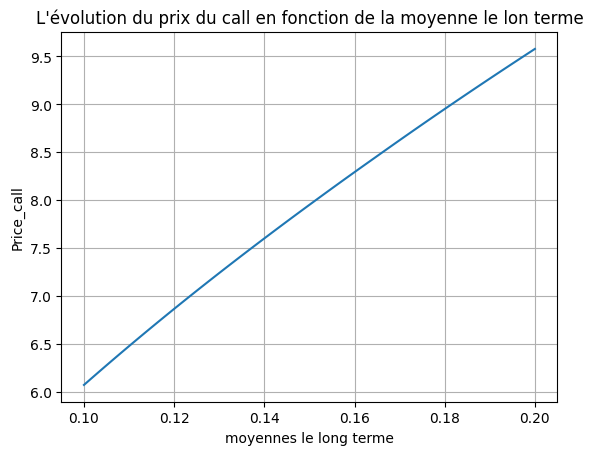

In [ ]:
thetas=np.linspace(0.1,0.2,100)
prix=[]
for theta in thetas:
  prix.append(Price_Heston_mc(100,0.04,0.03,100,1.0,100,100,2.5,theta,-0.7 ,0.35))
plt.plot(thetas,prix)
plt.title("L'évolution du prix du call en fonction de la moyenne le lon terme")
plt.xlabel("moyennes le long terme")
plt.ylabel("Price_call")
plt.grid(True)

Le prix du call est une fonction croissante de la moyenne de long terme de la variance. Une augmentation de ce paramètre accroît la volatilité moyenne anticipée et la dispersion du prix terminal, ce qui augmente la valeur de l'option.

##Prix du put estimé

In [ ]:
def Price_put_Heston_mc(S0, V0, r, K, T, M, N, kappa, theta, rho, sigma):
    dt = T / M
    payoffs = []
    np.random.seed(42)

    for i in range(N):
        S = S0
        V = V0
        for k in range(M):
            Z1 = np.random.randn()
            Z2 = np.random.randn()
            W1 = Z1
            W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
            V = V + kappa * (theta - np.maximum(V, 0.0)) * dt + sigma * np.sqrt(np.maximum(V, 0.0)) * np.sqrt(dt) * W2
            S = S * np.exp((r - 0.5 * np.maximum(V, 0.0)) * dt + np.sqrt(np.maximum(V, 0.0)) * np.sqrt(dt) * W1)
        payoffs.append(np.maximum(K - S, 0.0))

    price_put = np.exp(-r * T) * np.mean(payoffs)
    return price_put

In [ ]:
Price_put_Heston_mc(100,0.04,0.03,100,1.0,100,100,2.5,0.04,-0.7 ,0.35)

np.float64(11.93923529561691)

#La sensibilité du prix du put au mouvement de la corrélation entre des browniens

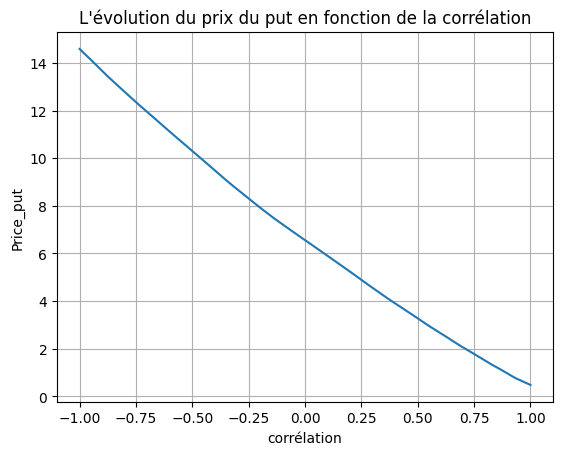

In [ ]:
cors=np.linspace(-1,1,100)
pri=[]
for rho in cors:
  pri.append(Price_put_Heston_mc(100,0.04,0.03,100,1.0,100,100,2.5,0.04,rho ,0.35))
plt.plot(cors,pri)
plt.title("L'évolution du prix du put en fonction de la corrélation")
plt.xlabel("corrélation")
plt.ylabel("Price_put")
plt.grid(True)

Le prix du put est une fonction décroissante de la corrélation entre les mouvements browniens du sous-jacent et de la variance. Une corrélation négative accroît la probabilité de baisses extrêmes du sous-jacent, ce qui augmente la valeur du put, tandis qu'une corrélation positive produit l'effet inverse.

##Sensibilité du prix du put aux mouvement du taux d'intérêt

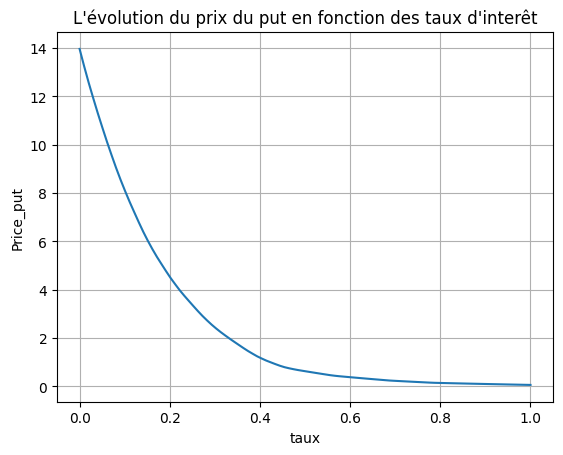

In [ ]:
taux=np.linspace(0,1,100)
pri=[]
for r in taux:
  pri.append(Price_put_Heston_mc(100,0.04,r,100,1.0,100,100,2.5,0.04,-0.7 ,0.35))
plt.plot(taux,pri)
plt.title("L'évolution du prix du put en fonction des taux d'interêt")
plt.xlabel("taux")
plt.ylabel("Price_put")
plt.grid(True)

Le prix du put est une fonction décroissante du taux d'intérêt sans risque. L'augmentation du taux réduit la valeur actualisée du strike et rend les scénarios de baisse du sous-jacent moins probables, ce qui diminue la valeur de l'option.

##Sensibilité du prix du put aux mouvement de la maturités

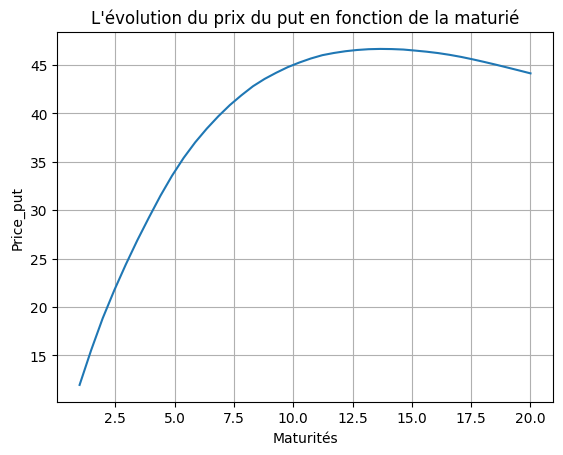

In [ ]:
Maturités=np.linspace(1,20,40)
pri=[]
for T in Maturités:
  pri.append(Price_put_Heston_mc(100,0.04,0.03,100,T,100,100,2.5,0.04,-0.7 ,0.35))
plt.plot(Maturités,pri)
plt.title("L'évolution du prix du put en fonction de la maturié")
plt.xlabel("Maturités")
plt.ylabel("Price_put")
plt.grid(True)

Le prix du put présente une relation non monotone avec la maturité: il augmente d'abord sous l'effet de la valeur temps, puis diminue lorsque l'actualisation du strike devient dominante pour les maturités longues.

##Sensibilités du prix du put aux mouvement du strike

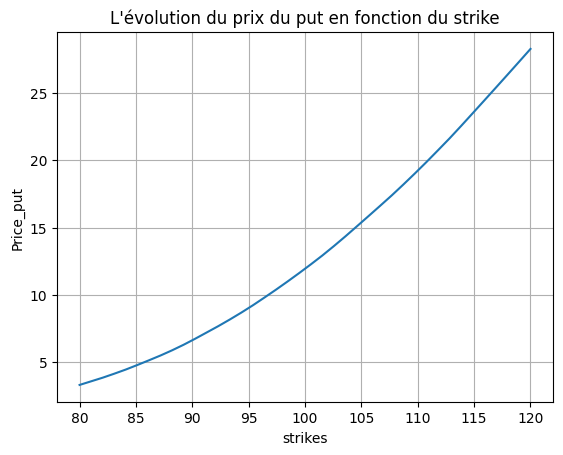

In [ ]:
strikes=np.linspace(80,120,40)
pri=[]
for K in strikes:
  pri.append(Price_put_Heston_mc(100,0.04,0.03,K,1.0,100,100,2.5,0.04,-0.7 ,0.35))
plt.plot(strikes,pri)
plt.title("L'évolution du prix du put en fonction du strike")
plt.xlabel("strikes")
plt.ylabel("Price_put")
plt.grid(True)

Le prix du put est une fonction croissante du strike. Une augmentation du prix d'exercice accroît la probabilité et l'ampleur des scénarios de baisse couverts par l'option, ce qui augmente la valeur de l'option.

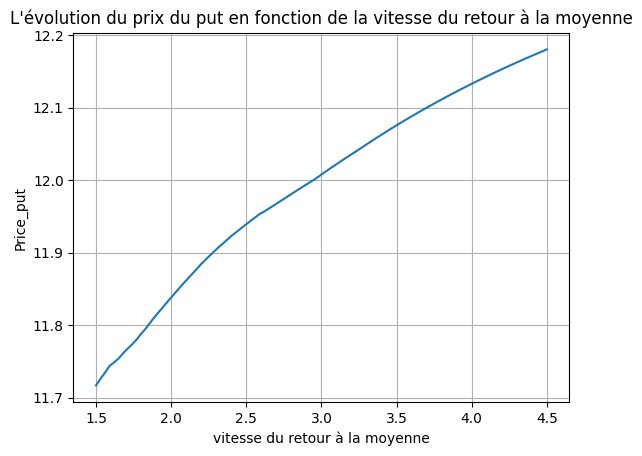

In [ ]:
kappas=np.linspace(1.5,4.5,100)
pri=[]
for kappa in kappas:
  pri.append(Price_put_Heston_mc(100,0.04,0.03,100,1.0,100,100,kappa,0.04,-0.7 ,0.35))
plt.plot(kappas,pri)
plt.title("L'évolution du prix du put en fonction de la vitesse du retour à la moyenne")
plt.xlabel("vitesse du retour à la moyenne")
plt.ylabel("Price_put")
plt.grid(True)

Le prix du put est une fonction croissante de la vitesse de retour à la moyenne de la variance. Une augmentation de ce paramètre stabilise la volatilité autour de son niveau de long terme et augmente la valeur espérée du payoff de l’option.

##Sensibilité du prix du call aux mouvements de la moyenne à long terme de la volatilité

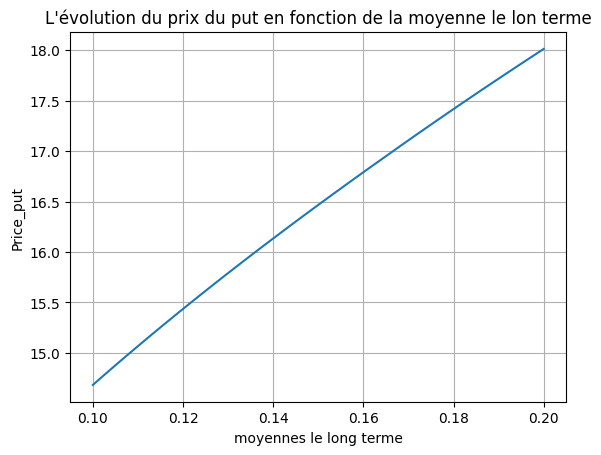

In [ ]:
thetas=np.linspace(0.1,0.2,100)
pri=[]
for theta in thetas:
  pri.append(Price_put_Heston_mc(100,0.04,0.03,100,1.0,100,100,2.5,theta,-0.7 ,0.35))
plt.plot(thetas,pri)
plt.title("L'évolution du prix du put en fonction de la moyenne le lon terme")
plt.xlabel("moyennes le long terme")
plt.ylabel("Price_put")
plt.grid(True)

Le prix du put est une fonction croissante de la moyenne de long terme de la variance. Une augmentation de ce paramètre accroît la volatilité moyenne anticipée et la dispersion du prix terminal, ce qui augmente la valeur de l'option.

##Méthode par changement de variable

Par construction, $V_t$ est positive .
Alors posons: $X_t = \ln V_t$


Par Itô, on a: $$dX_t = \frac{1}{V_t} \, dV_t - \frac{1}{2 V_t^2} \, d\langle V \rangle_t.$$ Or,
$$d\langle V \rangle_t = \sigma^2 V_t \, dt$$
donc $$dX_t = e^{-X_t} \, dV_t - \frac{1}{2} e^{-2X_t} \sigma^2 V_t \, dt$$.

En remplaçant $dV_t$ :
$$
\begin{aligned}
dX_t
&= e^{-X_t} \kappa(\theta - e^{X_t})\, dt
 + \sigma e^{-X_t} e^{\frac{X_t}{2}} dW_t^{2}
 - \frac{1}{2} \sigma^2 e^{-X_t} dt.
\end{aligned}
$$


Ainsi,
$$
dX_t
= e^{-X_t} \left[ \kappa(\theta - e^{X_t}) - \frac{1}{2}\sigma^2 \right] dt
+ \sigma e^{-\frac{X_t}{2}} dW_t^{2}.
$$

Schéma d'Euler:
$$
X_{t_{k+1}}
= X_{t_k}
+ e^{-X_{t_k}} \left[ \kappa(\theta - e^{X_{t_k}}) - \frac{1}{2}\sigma^2 \right]\Delta t
+ \sigma e^{-\frac{X_{t_k}}{2}} \sqrt{\Delta t}\, Z_{2,k},
$$
avec $Z_{2,k} \sim \mathcal{N}(0,1)$.

On a : $V_t = e^{X_t}$.

Le schéma pour le prix s'écrit :
$$
S_{t_{k+1}}
= S_{t_k}
\exp\!\left[
\left(r - \frac{1}{2} V_{t_k}\right)\Delta t
+ \sqrt{V_{t_k}}\,\sqrt{\Delta t}\, Z_{1,k}
\right].
$$

Avec $Z_{1,k}= \rho Z_{2,k} + \sqrt{1-\rho^2}\, Z_k,$
avec $Z \sim \mathcal{N}(0,1)$ et
$Z_k \perp Z_{2,k}$.

## Meme algorithme


## Trajectoire du sous-jacent et de la volatilités

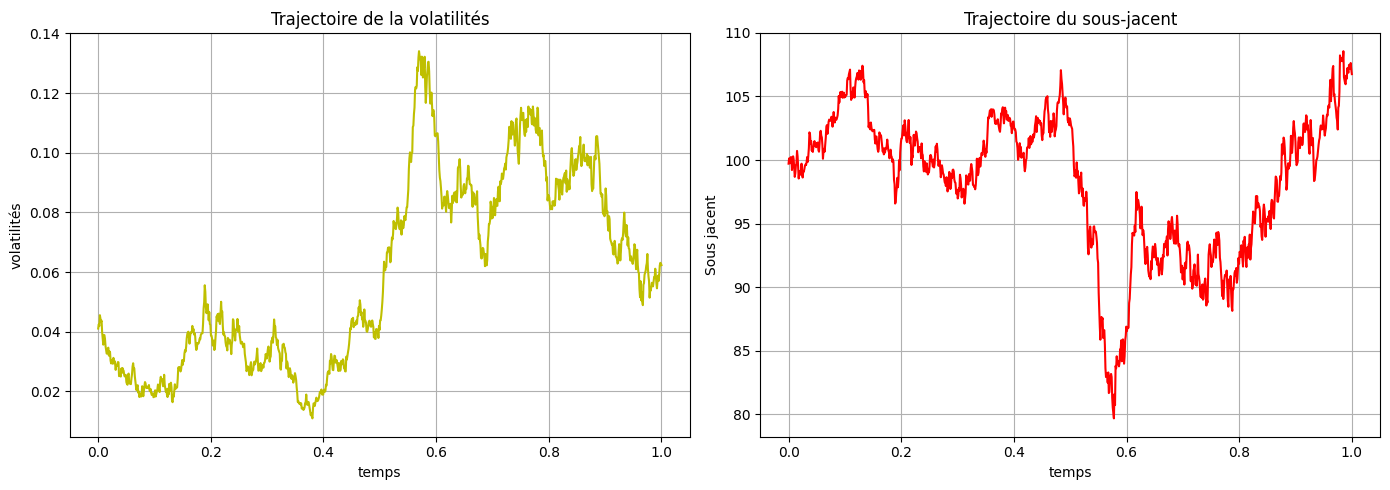

In [ ]:
def Simulation_Heston_g(S0, V0, r, K, T, N, kappa, theta, rho, sigma):
    dt = T / N
    t = np.linspace(0, 1, N)
    X = np.log(V0)
    S = S0
    voll = []
    traje = []
    np.random.seed(42)

    for k in range(N):
        Z1 = np.random.randn()
        X = np.clip(X, -50.0, 50.0)
        expX = np.exp(np.clip(X, -700.0, 700.0))
        X = X + np.exp(-np.clip(X, -700.0, 700.0)) * (kappa * (theta - expX) - 0.5 * sigma**2) * dt \
              + sigma * np.exp(-0.5 * np.clip(X, -700.0, 700.0)) * np.sqrt(dt) * Z1
        V = np.exp(np.clip(X, -700.0, 700.0))
        Z = rho * Z1 + np.sqrt(1 - rho**2) * np.random.randn()
        S = S * np.exp((r - 0.5 * V) * dt + np.sqrt(dt) * np.sqrt(V) * Z)
        voll.append(V)
        traje.append(S)

    return t, voll, traje
t,voll,traje=Simulation_Heston_g(100,0.04,0.03,100,1.0,1000,2.5,0.04,-0.7 ,0.35)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(t, voll,'y')
plt.title("Trajectoire de la volatilités")
plt.xlabel("temps")
plt.ylabel("volatilités")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t, traje,'r')
plt.title("Trajectoire du sous-jacent")
plt.xlabel("temps")
plt.ylabel("Sous jacent")
plt.grid(True)

plt.tight_layout()
plt.show()

##Prix du call estimé

In [ ]:
def Price_Heston_mc_g(S0, V0, r, K, T, M, N, kappa, theta, rho, sigma):
    dt = T / M
    payoffs = []
    np.random.seed(42)

    for i in range(N):
        S = S0
        X = np.log(V0)
        for k in range(M):
            Z1 = np.random.randn()
            Z2 = np.random.randn()
            W1 = Z1
            W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
            X = np.clip(X, -50.0, 50.0)
            expX = np.exp(np.clip(X, -700.0, 700.0))
            X = X + np.exp(-np.clip(X, -700.0, 700.0)) * (kappa * (theta - expX) - 0.5 * sigma**2) * dt \
              + sigma * np.exp(-0.5 * np.clip(X, -700.0, 700.0)) * np.sqrt(dt) * W1
            V = np.exp(np.clip(X, -700.0, 700.0))
            Z = rho * Z1 + np.sqrt(1 - rho**2) * np.random.randn()
            S = S * np.exp((r - 0.5 * V) * dt + np.sqrt(dt) * np.sqrt(V) * Z)
        ST=S
        payoffs.append(np.maximum(S - K, 0.0))

    price_call = np.exp(-r * T) * np.mean(payoffs)
    return price_call

In [ ]:
Price_Heston_mc_g(100,0.04,0.03,100,1.0,100,100,2.5,0.04,-0.7 ,0.35)

np.float64(2.741110637443376)

##Prix du put extimé

In [ ]:
def Price_put_Heston_mc_g(S0, V0, r, K, T, M, N, kappa, theta, rho, sigma):
    dt = T / M
    payoffs = []
    np.random.seed(42)

    for i in range(N):
        S = S0
        X = np.log(V0)
        for k in range(M):
            Z1 = np.random.randn()
            Z2 = np.random.randn()
            W1 = Z1
            W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
            X = np.clip(X, -50.0, 50.0)
            expX = np.exp(np.clip(X, -700.0, 700.0))
            X = X + np.exp(-np.clip(X, -700.0, 700.0)) * (kappa * (theta - expX) - 0.5 * sigma**2) * dt \
              + sigma * np.exp(-0.5 * np.clip(X, -700.0, 700.0)) * np.sqrt(dt) * W1
            V = np.exp(np.clip(X, -700.0, 700.0))
            Z = rho * Z1 + np.sqrt(1 - rho**2) * np.random.randn()
            S = S * np.exp((r - 0.5 * V) * dt + np.sqrt(dt) * np.sqrt(V) * Z)
        ST=S
        payoffs.append(np.maximum(K-S, 0.0))

    price_put = np.exp(-r * T) * np.mean(payoffs)
    return price_put

In [ ]:
Price_put_Heston_mc_g(100,0.04,0.03,100,1.0,100,100,2.5,0.04,-0.7 ,0.35)

np.float64(12.64519807949004)